# Corrected main prefix comparison

Scope: **IPv4 overall traffic**, **native** selected-prefix membership, and fixed Raw-derived prefixes compared under **Raw** and **Broad** conditions. Canonical `src_ip` and `dst_ip` retain first-observed direction; they are not initiator/responder roles.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D

from mawi_global_analysis.comparison import build_comparison_flow_inclusion
from mawi_global_analysis.io import load_run

root = Path(os.environ.get('MAWI_ANALYSIS_ROOT', '.')).resolve()
dataset_id = os.environ.get('MAWI_DATASET_ID', 'fixture')
run_name = os.environ.get('MAWI_RUN_NAME', 'baseline')
run = load_run(dataset_id, run_name, root=root)
provenance = pd.DataFrame([{'dataset': dataset_id, 'run_name': run_name, 'analysis_scope': 'IPv4 overall / native prefixes / Raw-Broad', 'config_hash': run.manifest.get('config', {}).get('hash'), 'input_sha256': run.manifest.get('input', {}).get('sha256'), 'git_commit': run.manifest.get('git_commit')}])
display(provenance)

,dataset,run_name,analysis_scope,config_hash,input_sha256,git_commit
0,202604081400,scan_source_driven_removal,IPv4 overall / native prefixes / Raw-Strict-Broad,b655de050c9e13fddb3c059325076c931682e20337cbb8...,5869ff3cd1b8cbe247def8c50fc5eb0d5d0c8df84222d3...,6c8ff335787cf290ac94fd0e07449134490cdfc2


## Canonical-table derivation

All views below are derived here from canonical `flows.csv`, M5-produced run-local `flow_labels.csv`, the fixed Raw-derived prefix ledger, and its fixed `flow_prefix_membership.csv`; no plot-specific pipeline data is read. The M6-A inclusion API is applied to the full canonical flow/label set before the IPv4 overall scope is selected.

In [2]:
# Build decisions on the complete canonical flow set; do not subset flows before M6-A validation.
inclusion = build_comparison_flow_inclusion(run.flows, run.labels)
flow_metrics = run.flows.merge(inclusion, on='flow_id', how='inner', validate='one_to_one')
ipv4_flows = flow_metrics.loc[pd.to_numeric(flow_metrics['ip_version']) == 4]
raw_flows = ipv4_flows
selected_prefixes = run.prefixes.loc[run.prefixes['selected_for_analysis'] == True, ['prefix', 'prefix_length', 'seen_as_src_prefix', 'seen_as_dst_prefix']].copy()
native_membership = run.membership.loc[run.membership['analysis_scope'] == 'native'].copy()
selected_prefix_ids = set(selected_prefixes['prefix'])
if not set(native_membership['flow_id']).issubset(set(inclusion['flow_id'])):
    raise ValueError('native membership contains a flow_id outside the canonical flow set')
if not set(native_membership['analysis_prefix']).issubset(selected_prefix_ids):
    raise ValueError('native membership contains a prefix outside the fixed Raw-derived selected set')
prefix_flow_columns = ['flow_id', 'packet_count', 'frame_byte_count', 'ip_byte_count', 'duration', 'raw_included', 'strict_included', 'broad_included']
prefix_flows = native_membership.merge(ipv4_flows.loc[:, prefix_flow_columns], on='flow_id', how='inner', validate='many_to_one')
selected_scope_flows = raw_flows.loc[raw_flows['flow_id'].isin(native_membership['flow_id'].unique())]
display(pd.DataFrame([{'ipv4_raw_flow_count': len(raw_flows), 'selected_native_prefix_count': len(selected_prefixes), 'native_membership_rows': len(native_membership), 'unique_flows_matching_any_native_prefix': native_membership['flow_id'].nunique()}]))
display(selected_prefixes.sort_values('prefix').head(20))

,ipv4_raw_flow_count,selected_native_prefix_count,native_membership_rows,unique_flows_matching_any_native_prefix
0,33295132,18,550289,549990


,prefix,prefix_length,seen_as_src_prefix,seen_as_dst_prefix
6,131.142.206.160/32,32,False,True
7,131.142.238.168/32,32,False,True
11,133.132.116.53/32,32,True,False
16,142.11.234.5/32,32,True,False
23,150.217.137.141/32,32,True,False
24,150.217.140.38/32,32,True,False
27,151.34.117.44/32,32,True,False
30,157.53.116.0/28,28,False,True
31,157.53.116.16/28,28,False,True
32,157.53.44.81/32,32,True,False


## Raw / Broad comparison tables

These are comparison-ready tables only. They keep the same Raw-derived native prefix set and membership for every condition; comparative visualizations are deferred to M6-B2.

In [3]:
conditions = pd.DataFrame({'condition': ['Raw', 'Broad'], 'inclusion_column': ['raw_included', 'broad_included']})
count_columns = ['flow_count', 'packet_count', 'frame_byte_count']

def condition_metrics(frame, condition, inclusion_column):
    survivors = frame.loc[frame[inclusion_column]]
    return {'condition': condition, 'flow_count': len(survivors), 'packet_count': survivors['packet_count'].sum(), 'frame_byte_count': survivors['frame_byte_count'].sum(), 'median_packet_count': survivors['packet_count'].median(), 'median_frame_byte_count': survivors['frame_byte_count'].median(), 'median_duration': survivors['duration'].median()}

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.where(denominator > 0))

overall_condition_summary = pd.DataFrame([condition_metrics(ipv4_flows, row.condition, row.inclusion_column) for row in conditions.itertuples(index=False)])
raw_overall = overall_condition_summary.loc[overall_condition_summary['condition'] == 'Raw'].iloc[0]
overall_removal_rows = []
for row in overall_condition_summary.loc[overall_condition_summary['condition'] == 'Broad'].itertuples(index=False):
    overall_removal_rows.append({'condition': row.condition, 'removed_flow_count': raw_overall.flow_count - row.flow_count, 'removed_flow_ratio': (raw_overall.flow_count - row.flow_count) / raw_overall.flow_count if raw_overall.flow_count else np.nan, 'removed_packet_count': raw_overall.packet_count - row.packet_count, 'removed_packet_ratio': (raw_overall.packet_count - row.packet_count) / raw_overall.packet_count if raw_overall.packet_count else np.nan, 'removed_frame_byte_count': raw_overall.frame_byte_count - row.frame_byte_count, 'removed_frame_byte_ratio': (raw_overall.frame_byte_count - row.frame_byte_count) / raw_overall.frame_byte_count if raw_overall.frame_byte_count else np.nan})
overall_removal_summary = pd.DataFrame(overall_removal_rows)

prefix_condition_index = selected_prefixes.loc[:, ['prefix']].rename(columns={'prefix': 'analysis_prefix'}).merge(conditions.loc[:, ['condition', 'inclusion_column']], how='cross')
prefix_condition_metrics = []
for row in conditions.itertuples(index=False):
    survivors = prefix_flows.loc[prefix_flows[row.inclusion_column]]
    metrics = survivors.groupby('analysis_prefix', as_index=False).agg(flow_count=('flow_id', 'size'), packet_count=('packet_count', 'sum'), frame_byte_count=('frame_byte_count', 'sum'), median_packet_count=('packet_count', 'median'), median_frame_byte_count=('frame_byte_count', 'median'), median_duration=('duration', 'median'))
    metrics['condition'] = row.condition
    prefix_condition_metrics.append(metrics)
per_prefix_condition_summary = prefix_condition_index.drop(columns='inclusion_column').merge(pd.concat(prefix_condition_metrics, ignore_index=True), on=['analysis_prefix', 'condition'], how='left', validate='one_to_one')
per_prefix_condition_summary.loc[:, count_columns] = per_prefix_condition_summary.loc[:, count_columns].fillna(0)

raw_prefix_metrics = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Raw', ['analysis_prefix', *count_columns]].rename(columns={column: f'raw_{column}' for column in count_columns})
per_prefix_removal_rows = []
for condition in ['Broad']:
    survivors = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, ['analysis_prefix', *count_columns]]
    comparison = raw_prefix_metrics.merge(survivors, on='analysis_prefix', how='left', validate='one_to_one')
    per_prefix_removal_rows.append(pd.DataFrame({'analysis_prefix': comparison['analysis_prefix'], 'condition': condition, 'removed_flow_count': comparison['raw_flow_count'] - comparison['flow_count'], 'removed_flow_ratio': safe_ratio(comparison['raw_flow_count'] - comparison['flow_count'], comparison['raw_flow_count']), 'removed_packet_count': comparison['raw_packet_count'] - comparison['packet_count'], 'removed_packet_ratio': safe_ratio(comparison['raw_packet_count'] - comparison['packet_count'], comparison['raw_packet_count']), 'removed_frame_byte_count': comparison['raw_frame_byte_count'] - comparison['frame_byte_count'], 'removed_frame_byte_ratio': safe_ratio(comparison['raw_frame_byte_count'] - comparison['frame_byte_count'], comparison['raw_frame_byte_count'])}))
per_prefix_removal_summary = pd.concat(per_prefix_removal_rows, ignore_index=True)

strict_overall_count = int(ipv4_flows['strict_included'].sum())
broad_overall_count = int(ipv4_flows['broad_included'].sum())
raw_overall_count = int(ipv4_flows['raw_included'].sum())
if not (broad_overall_count <= strict_overall_count <= raw_overall_count):
    raise ValueError('internal removal invariant violates Broad <= Strict <= Raw')
overall_counts = overall_condition_summary.set_index('condition')['flow_count']
prefix_counts_by_condition = per_prefix_condition_summary.groupby('condition')['analysis_prefix'].nunique().reindex(conditions['condition'])
if not (overall_counts['Broad'] <= overall_counts['Raw']):
    raise ValueError('overall survivor counts violate Broad <= Raw')
if not (prefix_counts_by_condition == len(selected_prefixes)).all():
    raise ValueError('a comparison condition does not retain the complete fixed Raw-derived prefix set')
for condition in conditions['condition']:
    condition_prefixes = set(per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, 'analysis_prefix'])
    if condition_prefixes != selected_prefix_ids:
        raise ValueError('a comparison condition changed the fixed Raw-derived prefix set')
sanity_summary = pd.DataFrame([{'raw_selected_native_prefix_count': len(selected_prefixes), 'raw_table_prefix_count': prefix_counts_by_condition['Raw'], 'broad_table_prefix_count': prefix_counts_by_condition['Broad'], 'broad_zero_surviving_prefix_count': int((per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Broad', 'flow_count'] == 0).sum()), 'raw_overall_flow_count': overall_counts['Raw'], 'broad_overall_flow_count': overall_counts['Broad']}])

display(overall_condition_summary)
display(overall_removal_summary)
display(per_prefix_condition_summary.sort_values(['condition', 'analysis_prefix']))
display(per_prefix_removal_summary.sort_values(['condition', 'analysis_prefix']))
display(sanity_summary)

,condition,flow_count,packet_count,frame_byte_count,median_packet_count,median_frame_byte_count,median_duration
0,Raw,33295132,189938960,10293558638,1.0,58.0,0.0
1,Strict,33073852,183246410,9872602042,1.0,58.0,0.0
2,Broad,24388116,172401916,9235537726,1.0,58.0,0.0


,condition,removed_flow_count,removed_flow_ratio,removed_packet_count,removed_packet_ratio,removed_frame_byte_count,removed_frame_byte_ratio
0,Strict,221280,0.006646,6692550,0.035235,420956596,0.040895
1,Broad,8907016,0.267517,17537044,0.092330,1058020912,0.102785


,analysis_prefix,condition,flow_count,packet_count,frame_byte_count,median_packet_count,median_frame_byte_count,median_duration
2,131.142.206.160/32,Broad,975,2033337,97682030,10.0,504.0,0.477406
5,131.142.238.168/32,Broad,8015,3558360,155021564,9.0,498.0,1.473219
8,133.132.116.53/32,Broad,38876,3585438,176007020,14.0,630.0,0.674561
11,142.11.234.5/32,Broad,493,39061,1775734,37.0,1638.0,0.479875
14,150.217.137.141/32,Broad,56431,7244282,463890180,11.0,742.0,1.396931
17,150.217.140.38/32,Broad,39,47,2622,1.0,58.0,0.000000
20,151.34.117.44/32,Broad,1819,956913,63176166,74.0,4892.0,3.370416
23,157.53.116.0/28,Broad,57989,6447702,331778060,9.0,510.0,0.635390
26,157.53.116.16/28,Broad,22894,4630652,226950140,9.0,490.0,0.578066
29,157.53.44.81/32,Broad,465,2866929,189220534,6604.0,435864.0,6.209449


,analysis_prefix,condition,removed_flow_count,removed_flow_ratio,removed_packet_count,removed_packet_ratio,removed_frame_byte_count,removed_frame_byte_ratio
18,131.142.206.160/32,Broad,19,0.019115,37,0.000018,2082,0.000021
19,131.142.238.168/32,Broad,786,0.089308,37699,0.010483,2113330,0.013449
20,133.132.116.53/32,Broad,62304,0.615774,1783404,0.332177,117568708,0.400471
21,142.11.234.5/32,Broad,99,0.167230,1035262,0.963641,69163756,0.974968
22,150.217.137.141/32,Broad,29,0.000514,305,0.000042,19890,0.000043
23,150.217.140.38/32,Broad,20,0.338983,20,0.298507,1116,0.298555
24,151.34.117.44/32,Broad,0,0.000000,0,0.000000,0,0.000000
25,157.53.116.0/28,Broad,10462,0.152839,191499,0.028844,11999494,0.034905
26,157.53.116.16/28,Broad,1983,0.079712,34733,0.007445,2222646,0.009699
27,157.53.44.81/32,Broad,0,0.000000,0,0.000000,0,0.000000


,raw_selected_native_prefix_count,raw_table_prefix_count,strict_table_prefix_count,broad_table_prefix_count,strict_zero_surviving_prefix_count,broad_zero_surviving_prefix_count,raw_overall_flow_count,strict_overall_flow_count,broad_overall_flow_count
0,18,18,18,18,0,0,33295132,33073852,24388116


## Raw / Broad visual comparison

These views show movement in the already-constructed comparison tables. They do not reclassify flows or change the fixed Raw-derived prefix set.

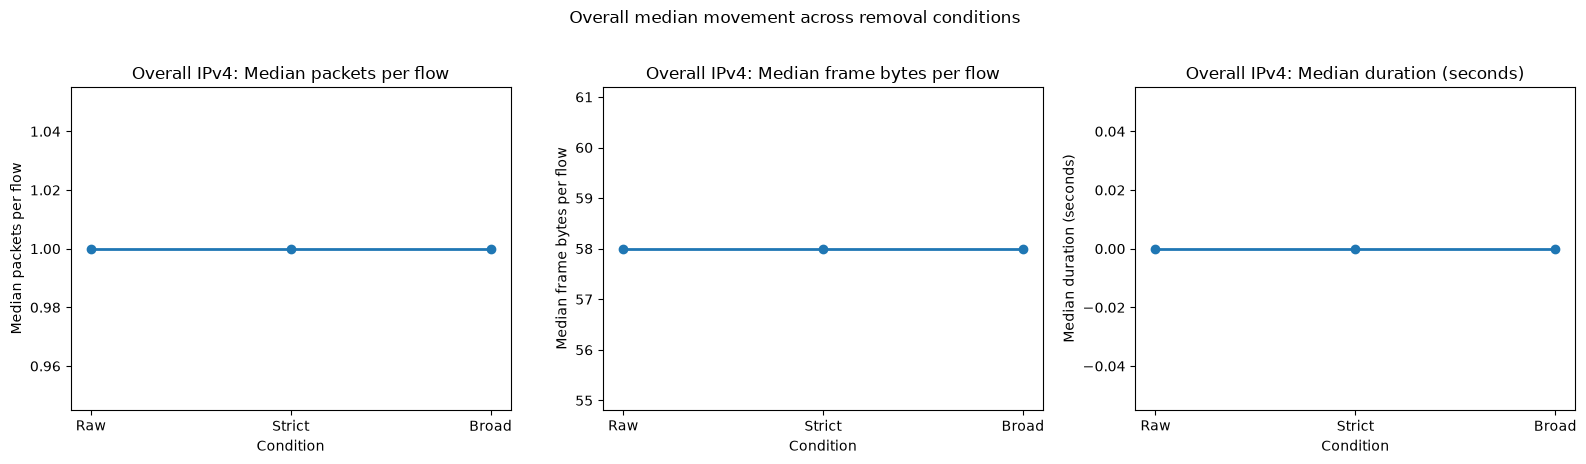

In [4]:
condition_order = ['Raw', 'Broad']
condition_labels = {'Raw': 'Raw', 'Broad': 'Broad removal'}
median_metrics = ['median_packet_count', 'median_frame_byte_count', 'median_duration']
metric_labels = {'median_packet_count': 'Median packets per flow', 'median_frame_byte_count': 'Median frame bytes per flow', 'median_duration': 'Median duration (seconds)'}
overall_medians = overall_condition_summary.set_index('condition').reindex(condition_order)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for axis, metric in zip(axes, median_metrics):
    axis.plot(condition_order, overall_medians[metric], marker='o', linewidth=2, color='tab:blue')
    axis.set(title=f'Overall IPv4: {metric_labels[metric]}', xlabel='Condition', ylabel=metric_labels[metric])
fig.suptitle('Overall median movement across removal conditions', y=1.02)
fig.tight_layout()

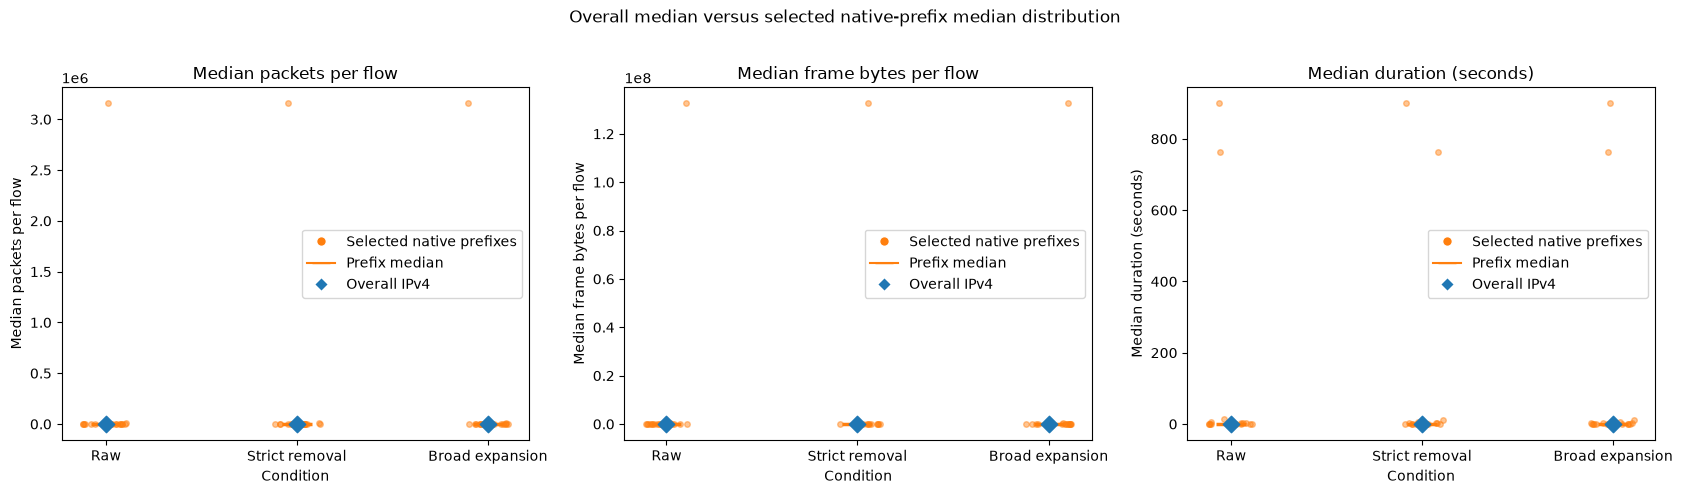

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
jitter = np.random.default_rng(0)
for axis, metric in zip(axes, median_metrics):
    for position, condition in enumerate(condition_order):
        values = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, metric].dropna()
        axis.scatter(position + jitter.uniform(-0.12, 0.12, len(values)), values, s=16, alpha=0.45, color='tab:orange', label='Selected native prefixes' if position == 0 else None)
        if not values.empty:
            axis.scatter(position, values.median(), marker='_', s=450, linewidths=2.5, color='tab:orange', zorder=2, label='Prefix median' if position == 0 else None)
        axis.scatter(position, overall_medians.loc[condition, metric], marker='D', s=70, color='tab:blue', zorder=3, label='Overall IPv4' if position == 0 else None)
    axis.set(title=metric_labels[metric], xlabel='Condition', ylabel=metric_labels[metric], xticks=range(len(condition_order)), xticklabels=[condition_labels[condition] for condition in condition_order])
    axis.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=7, label='Selected native prefixes'), Line2D([0], [0], marker='_', color='tab:orange', markersize=13, label='Prefix median'), Line2D([0], [0], marker='D', color='w', markerfacecolor='tab:blue', markersize=7, label='Overall IPv4')])
fig.suptitle('Overall median versus selected native-prefix median distribution', y=1.02)
fig.tight_layout()

### Per-prefix median change from Raw

Each point is one fixed `analysis_prefix`. Values closer to the identity line indicate less movement in that prefix median; rows with no surviving flows remain in the comparison table but have `NaN` medians and are not plotted.

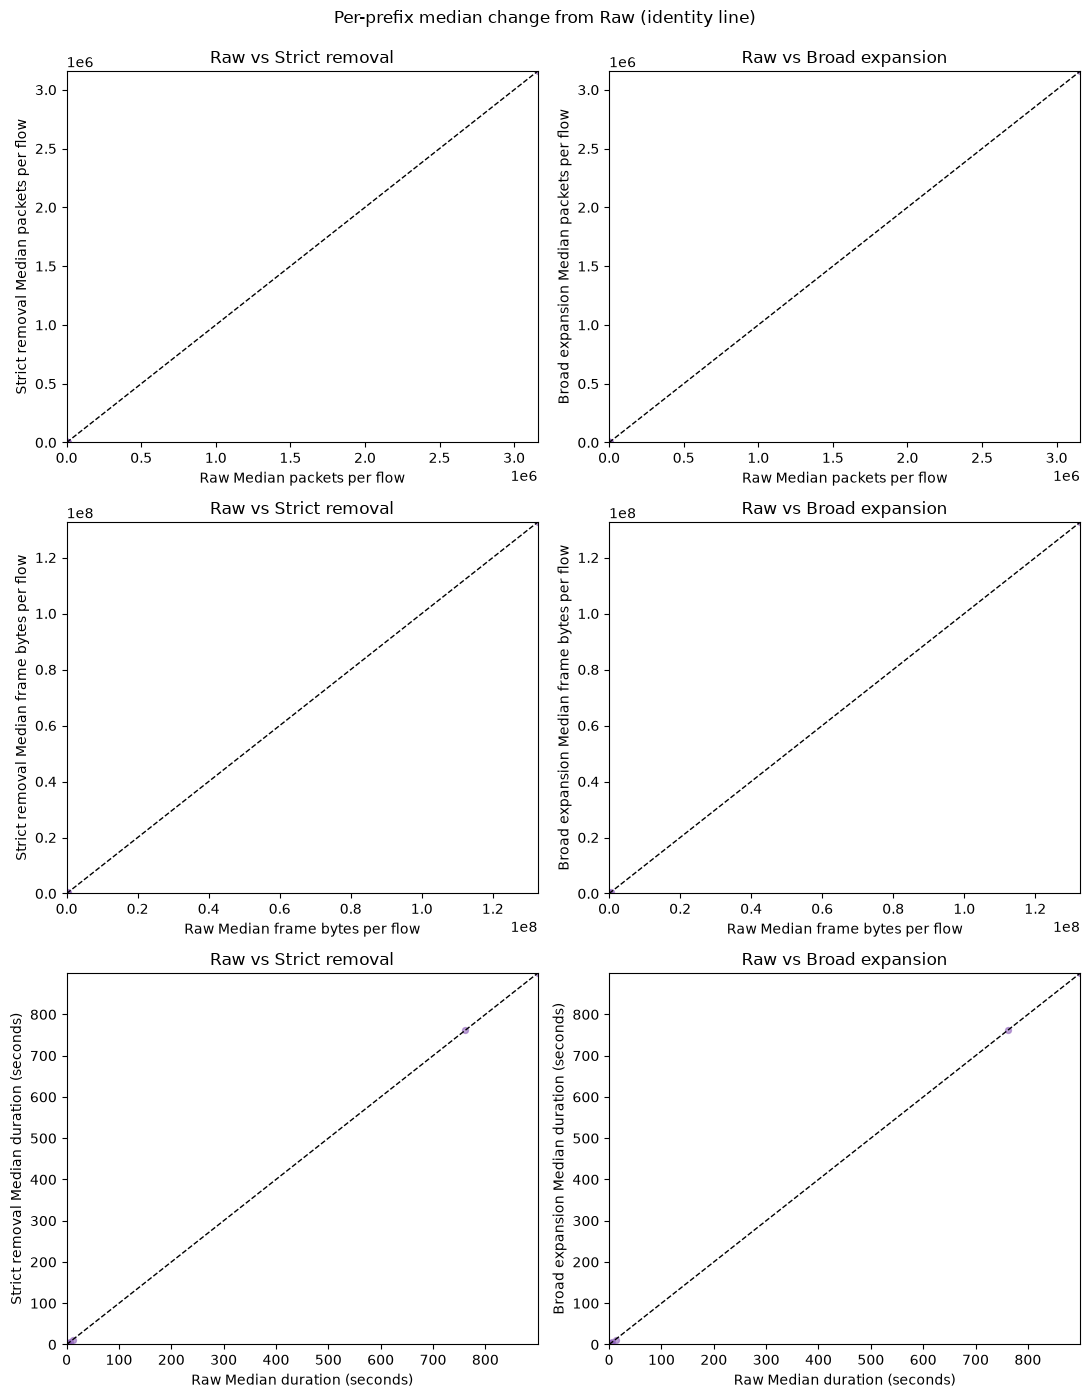

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(5.5, 14))
for row_index, metric in enumerate(median_metrics):
    raw_values = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == 'Raw', ['analysis_prefix', metric]].rename(columns={metric: 'raw_value'})
    condition = 'Broad'
    axis = axes[row_index]
    compared_values = per_prefix_condition_summary.loc[per_prefix_condition_summary['condition'] == condition, ['analysis_prefix', metric]].rename(columns={metric: 'condition_value'})
    paired = raw_values.merge(compared_values, on='analysis_prefix', how='inner', validate='one_to_one').dropna()
    if paired.empty:
        axis.text(0.5, 0.5, 'No paired surviving-prefix medians', ha='center', va='center', transform=axis.transAxes)
        axis.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
        axis.set(xlim=(0, 1), ylim=(0, 1))
    else:
        upper = max(paired['raw_value'].max(), paired['condition_value'].max(), 1)
        axis.scatter(paired['raw_value'], paired['condition_value'], s=18, alpha=0.6, color='tab:purple')
        axis.plot([0, upper], [0, upper], linestyle='--', color='black', linewidth=1)
        axis.set(xlim=(0, upper), ylim=(0, upper))
    axis.set(title=f'Raw vs {condition_labels[condition]}', xlabel=f'Raw {metric_labels[metric]}', ylabel=f'{condition_labels[condition]} {metric_labels[metric]}')
fig.suptitle('Per-prefix median change from Raw (identity line)', y=0.995)
fig.tight_layout()

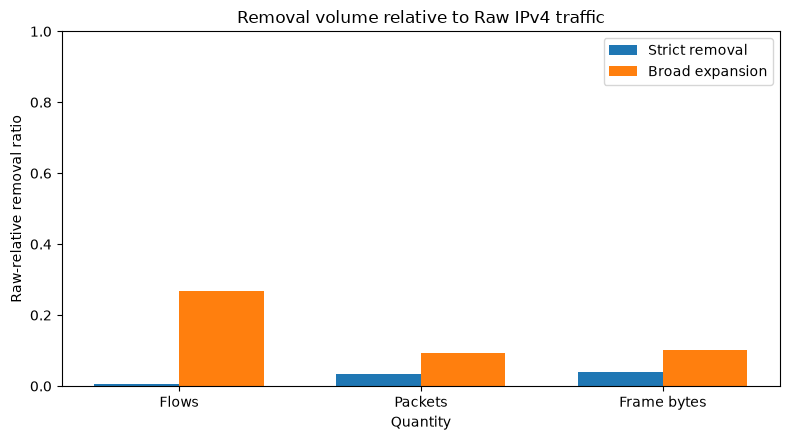

In [7]:
removal_metrics = ['removed_flow_ratio', 'removed_packet_ratio', 'removed_frame_byte_ratio']
removal_labels = ['Flows', 'Packets', 'Frame bytes']
removal_plot = overall_removal_summary.set_index('condition').reindex(['Broad'])
positions = np.arange(len(removal_metrics))
width = 0.55
fig, axis = plt.subplots(figsize=(8, 4.5))
condition = 'Broad'
axis.bar(positions, removal_plot.loc[condition, removal_metrics], width=width, label=condition_labels[condition])
axis.set(title='Removal volume relative to Raw IPv4 traffic', xlabel='Quantity', ylabel='Raw-relative removal ratio', xticks=positions, xticklabels=removal_labels, ylim=(0, 1))
axis.legend()
fig.tight_layout()

## Raw baseline descriptive distributions

These existing Raw-only flow-length views remain a baseline descriptive reference. Raw/Broad distribution comparisons are intentionally outside this descriptive section.

/tmp/ipykernel_14386/455148118.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


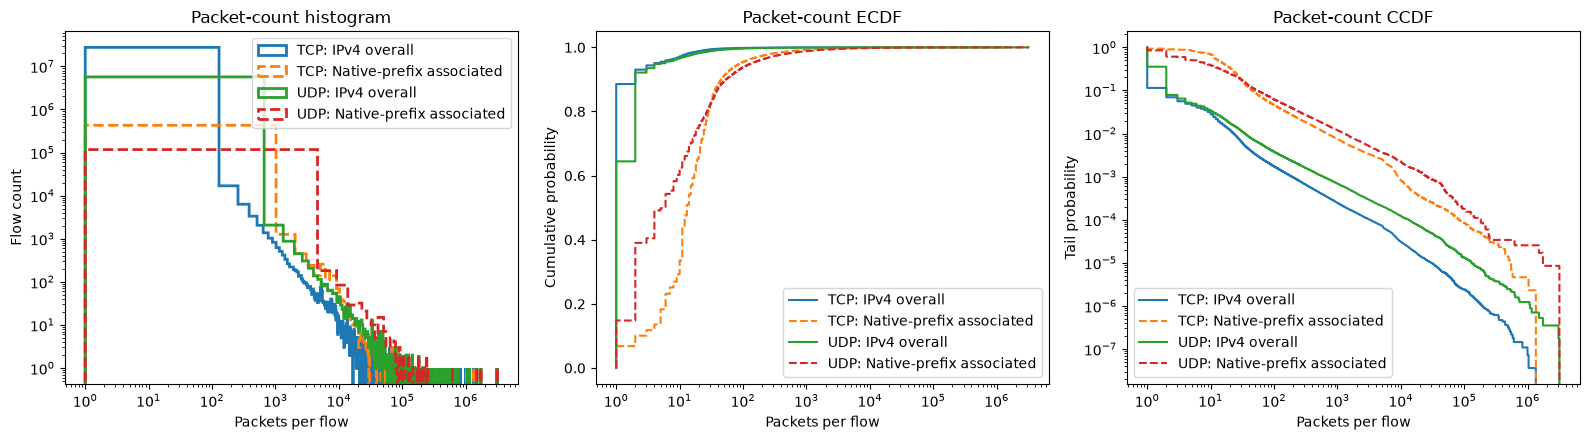

In [8]:
def ecdf(values):
    ordered = np.sort(np.asarray(values, dtype=float))
    return ordered, np.arange(1, len(ordered) + 1) / len(ordered)

protocols = {'TCP': ['6', '6.0', 'tcp'], 'UDP': ['17', '17.0', 'udp']}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for protocol, values in protocols.items():
    for scope, frame, style in [('IPv4 overall', raw_flows, '-'), ('Native-prefix associated', selected_scope_flows, '--')]:
        packets = frame.loc[frame['protocol'].astype(str).isin(values), 'packet_count']
        if packets.empty:
            continue
        x, y = ecdf(packets)
        label = f'{protocol}: {scope}'
        axes[0].hist(packets, bins='auto', histtype='step', linewidth=2, linestyle=style, label=label)
        axes[1].step(x, y, where='post', linestyle=style, label=label)
axes[0].set(title='Packet-count histogram', xlabel='Packets per flow', ylabel='Flow count', xscale='log', yscale='log')
axes[1].set(title='Packet-count ECDF', xlabel='Packets per flow', ylabel='Cumulative probability', xscale='log')
for axis in axes:
    axis.legend()
fig.tight_layout()

,selected_prefixes_with_zero_canonical_membership,selected_prefix_count
0,0,18


,analysis_prefix,prefix_length,seen_as_src_prefix,seen_as_dst_prefix,flow_count,packet_count,frame_byte_count,ip_byte_count,median_packet_count,median_frame_byte_count,median_duration,q90_duration,q99_duration
13,202.3.204.0/24,24,False,True,229548,24057826,1294747804,957938240,17.0,1006.0,0.810590,223.300856,840.105670
4,150.217.137.141/32,32,True,False,56460,7244587,463910070,362485852,11.0,742.0,1.395999,18.373334,840.156705
7,157.53.116.0/28,28,False,True,68451,6639201,343777554,250828740,9.0,510.0,0.642715,97.139827,771.090498
2,133.132.116.53/32,32,True,False,101180,5368842,293575728,218411940,13.0,804.0,1.201265,150.805117,840.149263
8,157.53.116.16/28,28,False,True,24877,4665385,229172786,163857396,8.0,470.0,0.562915,101.004357,753.541283
14,203.68.133.255/32,32,True,False,50116,3006832,198998512,156902864,11.0,742.0,0.081357,367.183676,788.587463
9,157.53.44.81/32,32,True,False,465,2866929,189220534,149083528,6604.0,435864.0,6.209449,6.561200,7.853359
11,172.41.213.92/32,32,False,True,3390,2850311,186353850,146449496,14.0,672.0,1.107490,305.120350,879.355268
10,163.29.158.43/32,32,True,False,289,2712887,178784914,140804496,17.0,888.0,3.132016,370.764742,803.999338
1,131.142.238.168/32,32,False,True,8801,3596059,157134894,106790068,10.0,528.0,1.718025,240.000565,714.261432


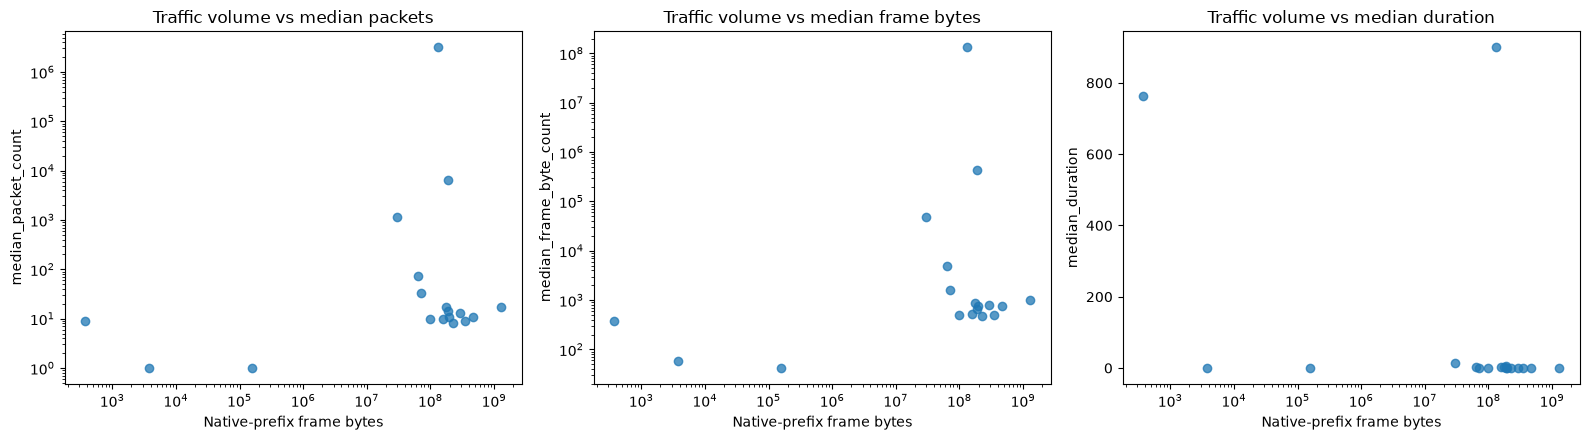

In [9]:
# One row for every selected native prefix, including prefixes with zero canonical membership.
prefix_metrics = prefix_flows.groupby('analysis_prefix', as_index=False).agg(flow_count=('flow_id', 'size'), packet_count=('packet_count', 'sum'), frame_byte_count=('frame_byte_count', 'sum'), ip_byte_count=('ip_byte_count', 'sum'), median_packet_count=('packet_count', 'median'), median_frame_byte_count=('frame_byte_count', 'median'), median_duration=('duration', 'median'), q90_duration=('duration', lambda values: values.quantile(0.9)), q99_duration=('duration', lambda values: values.quantile(0.99)))
prefix_summary = selected_prefixes.rename(columns={'prefix': 'analysis_prefix'}).merge(prefix_metrics, on='analysis_prefix', how='left', validate='one_to_one')
zero_volume_prefixes = prefix_summary['flow_count'].isna()
prefix_summary[['flow_count', 'packet_count', 'frame_byte_count', 'ip_byte_count']] = prefix_summary[['flow_count', 'packet_count', 'frame_byte_count', 'ip_byte_count']].fillna(0)
display(pd.DataFrame([{'selected_prefixes_with_zero_canonical_membership': int(zero_volume_prefixes.sum()), 'selected_prefix_count': len(prefix_summary)}]))
display(prefix_summary.sort_values('frame_byte_count', ascending=False).head(20))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
positive_volume = prefix_summary.loc[prefix_summary['frame_byte_count'] > 0]
for axis, y_column, title in zip(axes, ['median_packet_count', 'median_frame_byte_count', 'median_duration'], ['Traffic volume vs median packets', 'Traffic volume vs median frame bytes', 'Traffic volume vs median duration']):
    axis.scatter(positive_volume['frame_byte_count'], positive_volume[y_column], alpha=0.75)
    axis.set(xscale='log', yscale='log' if (positive_volume[y_column] > 0).all() else 'linear', xlabel='Native-prefix frame bytes', ylabel=y_column, title=title)
fig.tight_layout()

/tmp/ipykernel_14386/461750896.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/s-sakai/mawi-global-analysis/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


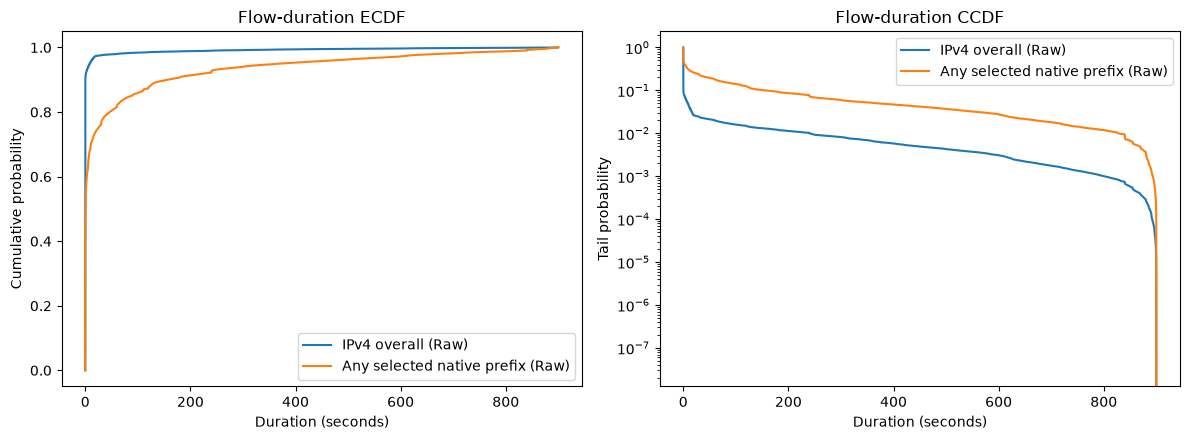

In [10]:
# The selected-prefix series is deduplicated by flow_id for this combined-scope view.
fig, axis = plt.subplots(figsize=(6, 4.5))
for label, values in [('IPv4 overall (Raw)', raw_flows['duration']), ('Any selected native prefix (Raw)', selected_scope_flows['duration'])]:
    x, y = ecdf(values)
    axis.step(x, y, where='post', label=label)
axis.set(title='Flow-duration ECDF', xlabel='Duration (seconds)', ylabel='Cumulative probability')
axis.legend()
fig.tight_layout()

This corrected baseline intentionally uses all selected non-overlapping native IPv4 prefixes. Prefix membership is `src_ip ∈ prefix OR dst_ip ∈ prefix`; `src_match` and `dst_match` remain observation-direction facts, not traffic-role labels.